In [1]:
import pandas as pd
import numpy as np
import os

from scipy.stats import mannwhitneyu, spearmanr

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/final/DatasetfinaleMaugeri.xlsx"

df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)

print(df["Output:"].value_counts())
print(df["Output Stage"].value_counts().sort_index())

Dataset shape: (195, 203)
Output:
PD    149
HS     46
Name: count, dtype: int64
Output Stage
0    46
1    49
2    50
3    50
Name: count, dtype: int64


In [3]:
asy_cols = [c for c in df.columns if "ASY" in c]

print("Numero colonne asimmetria:", len(asy_cols))

Numero colonne asimmetria: 120


In [4]:
def cliffs_delta(x, y):
    
    nx = len(x)
    ny = len(y)
    
    gt = 0
    lt = 0
    
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
        
    delta = (gt - lt) / (nx * ny)
    
    return delta

In [6]:
results_pdhs = []

pd_mask = df["Output:"] == "PD"
hs_mask = df["Output:"] == "HS"

for col in asy_cols:

    x = df.loc[pd_mask, col].dropna()
    y = df.loc[hs_mask, col].dropna()

    if len(x) > 0 and len(y) > 0:

        delta = cliffs_delta(x.values, y.values)

        results_pdhs.append({
            "metric": col,
            "effect": abs(delta),
            "analysis": "PD_vs_HS"
        })

pdhs_df = pd.DataFrame(results_pdhs)

pdhs_df.head()

,metric,effect,analysis
0,ASY1 Step_length: totale,0.263496,PD_vs_HS
1,ASY1 Stride_length: totale,0.245696,PD_vs_HS
2,ASY1 Supp_base: totale,0.120447,PD_vs_HS
3,ASY1 Step_time: totale,0.385177,PD_vs_HS
4,ASY1 Stride_time: totale,0.127517,PD_vs_HS


In [7]:
stage = df["Output Stage"]

results_hy = []

for col in asy_cols:

    x = df[col]

    mask = ~(x.isna())

    rho, p = spearmanr(x[mask], stage[mask])

    results_hy.append({
        "metric": col,
        "effect": abs(rho),
        "analysis": "HY_progression"
    })

hy_df = pd.DataFrame(results_hy)

hy_df.head()

,metric,effect,analysis
0,ASY1 Step_length: totale,0.297952,HY_progression
1,ASY1 Stride_length: totale,0.227876,HY_progression
2,ASY1 Supp_base: totale,0.123059,HY_progression
3,ASY1 Step_time: totale,0.280611,HY_progression
4,ASY1 Stride_time: totale,0.084148,HY_progression


In [8]:
pattern_formula = r"(ASY\d+)"

pattern_variable = r"(Step_length:|Stride_length:|Supp_base:|Step_time:|Stride_time:|Swing_time:|Stance_time:|Supp_time_Single:|Supp_time_Double:|Stride_velocity:)"

pdhs_df["formula"] = pdhs_df["metric"].str.extract(pattern_formula)
pdhs_df["variable"] = pdhs_df["metric"].str.extract(pattern_variable)

hy_df["formula"] = hy_df["metric"].str.extract(pattern_formula)
hy_df["variable"] = hy_df["metric"].str.extract(pattern_variable)

In [9]:
combined = pd.concat([pdhs_df, hy_df], ignore_index=True)

combined.head()

,metric,effect,analysis,formula,variable
0,ASY1 Step_length: totale,0.263496,PD_vs_HS,ASY1,Step_length:
1,ASY1 Stride_length: totale,0.245696,PD_vs_HS,ASY1,Stride_length:
2,ASY1 Supp_base: totale,0.120447,PD_vs_HS,ASY1,Supp_base:
3,ASY1 Step_time: totale,0.385177,PD_vs_HS,ASY1,Step_time:
4,ASY1 Stride_time: totale,0.127517,PD_vs_HS,ASY1,Stride_time:


In [10]:
model = smf.ols(
    "effect ~ C(formula) + C(variable)",
    data=combined
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 effect   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     33.25
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           3.25e-55
Time:                        14:44:13   Log-Likelihood:                 326.32
No. Observations:                 240   AIC:                            -610.6
Df Residuals:                     219   BIC:                            -537.6
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [11]:
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(formula),1.231290,11.0,26.465163,1.632558e-34
C(variable),1.581138,9.0,41.536921,1.129679e-42
Residual,0.926269,219.0,NaN,NaN


In [12]:
formula_mean = (
    combined
    .groupby("formula")["effect"]
    .mean()
    .sort_values(ascending=False)
)

formula_mean

formula
ASY10    0.233489
ASY3     0.233489
ASY1     0.232674
ASY6     0.231679
ASY7     0.231651
ASY11    0.231636
ASY4     0.231636
ASY9     0.231636
ASY12    0.210955
ASY2     0.065736
ASY5     0.064642
ASY8     0.064642
Name: effect, dtype: float64

In [13]:
variable_mean = (
    combined
    .groupby("variable")["effect"]
    .mean()
    .sort_values(ascending=False)
)

variable_mean

variable
Stance_time:         0.318430
Step_time:           0.268876
Supp_time_Single:    0.256597
Swing_time:          0.256300
Step_length:         0.210346
Stride_length:       0.165936
Supp_base:           0.135062
Stride_velocity:     0.119225
Stride_time:         0.087772
Supp_time_Double:    0.068010
Name: effect, dtype: float64

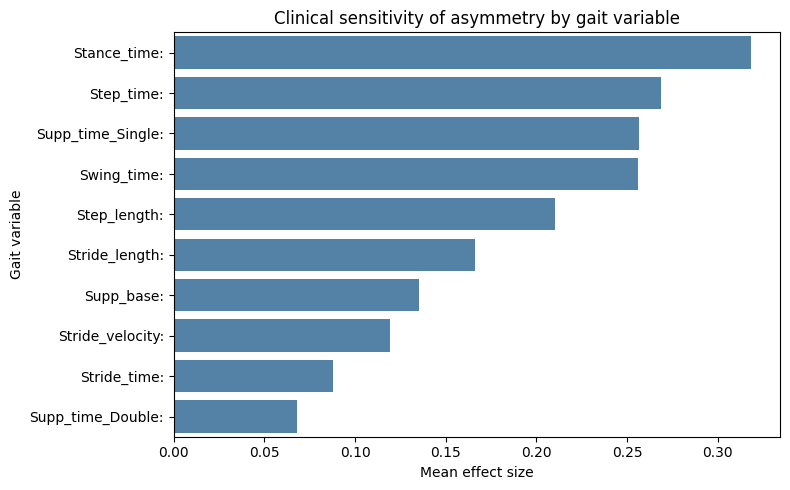

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=variable_mean.values,
    y=variable_mean.index,
    color="steelblue"
)

plt.xlabel("Mean effect size")
plt.ylabel("Gait variable")

plt.title("Clinical sensitivity of asymmetry by gait variable")

plt.tight_layout()

plt.show()

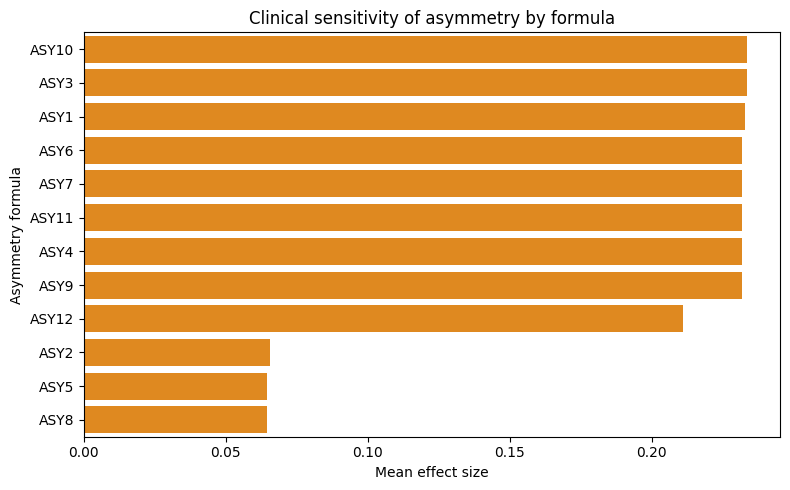

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=formula_mean.values,
    y=formula_mean.index,
    color="darkorange"
)

plt.xlabel("Mean effect size")
plt.ylabel("Asymmetry formula")

plt.title("Clinical sensitivity of asymmetry by formula")

plt.tight_layout()

plt.show()

1. Il dataset sta dicendo una cosa molto chiara

La sensibilità clinica dell’analisi di asimmetria dipende più dalla variabile gait che dalla formula matematica.

Questo è il messaggio principale del paper.

Non vuol dire che la formula sia irrilevante in assoluto. Vuol dire che, una volta escluse o ridimensionate le formule signed che si comportano male, la differenza vera la fa il dominio biomeccanico a cui applichi la formula.

In pratica:

conta molto se guardi Stance_time, Step_time, Supp_time_Single, Swing_time

conta molto meno se usi ASY1 o ASY3 o ASY4 o ASY7

conta davvero poco se continui a proliferare formule quasi equivalenti

Questo è esattamente il tipo di conclusione che ha valore metodologico.

2. Le due figure finali sono molto convincenti
Figura 1 — Clinical sensitivity by gait variable

Questa è probabilmente la figura più importante dell’intero lavoro.

Il ranking è nettissimo:

Stance_time: = 0.318

Step_time: = 0.269

Supp_time_Single: = 0.257

Swing_time: = 0.256

Poi c’è un gradino.

Step_length: = 0.210

Stride_length: = 0.166

Supp_base: = 0.135

Stride_velocity: = 0.119

Stride_time: = 0.088

Supp_time_Double: = 0.068

Tradotto brutalmente: le asimmetrie temporali dominano, le spaziali seguono, e alcune variabili sono francamente deboli.

Questo è molto coerente con il Parkinson. Il disturbo non si manifesta solo come “passi più corti”, ma come alterazione del timing bilaterale del cammino, soprattutto nelle fasi di supporto e trasferimento.

La gerarchia che emerge è molto pulita:

Stance phase asymmetry è il segnale più robusto.

Step time / single support / swing time costituiscono il nucleo temporale sensibile.

Le variabili spaziali aggiungono informazione, ma meno.

Supp_time_Double e Stride_time sono deboli come driver clinici.

Questa figura, da sola, giustifica l’idea che il problema non sia “quale formula usare?”, ma dove cercare il segnale.

3. La figura sulle formule è altrettanto importante, ma per un altro motivo

Il ranking delle formule dice:

ASY10 = 0.233

ASY3 = 0.233

ASY1 = 0.233

ASY6 = 0.232

ASY7 = 0.232

ASY11 = 0.232

ASY4 = 0.232

ASY9 = 0.232

ASY12 = 0.211

ASY2 = 0.066

ASY5 = 0.065

ASY8 = 0.065

Questa figura racconta due storie.

Storia A — enorme ridondanza

Tutta la famiglia:

ASY1

ASY3

ASY4

ASY6

ASY7

ASY9

ASY10

ASY11

è praticamente sovrapponibile.

Quindi la letteratura che continua a proporre varianti di queste formule, nella pratica, sta spesso riformulando lo stesso costrutto.

Storia B — le formule signed sono un problema

ASY2, ASY5, ASY8 stanno molto più in basso.

Questo non è un dettaglio. È un risultato metodologicamente importante.

Il motivo è chiaro: queste formule mantengono la direzione dell’asimmetria. In analisi di gruppo, specialmente nel PD, questo è spesso controproducente, perché i soggetti possono essere lateralizzati in direzioni opposte. Il segno allora si cancella e l’effetto medio collassa.

Quindi la conclusione non è solo “alcune formule sono migliori”.
È più precisa:

le formule di magnitudine dell’asimmetria sono clinicamente stabili; le formule signed sono inadatte come misura aggregata di sensibilità di gruppo.

Questo è un risultato forte.

4. L’OLS e l’ANOVA danno il colpo finale

Hai ottenuto:

R² = 0.752

C(formula) significativo, p ≈ 1.6e-34

C(variable) significativo, p ≈ 1.1e-42

Qui bisogna ragionare bene, senza raccontarsela.

Cosa significa davvero

Entrambi i fattori contano. Ma la variabile conta di più.

Lo si vede da:

sum_sq variabile = 1.581

sum_sq formula = 1.231

F variabile = 41.54

F formula = 26.47

Quindi sì, la formula contribuisce, ma meno della variabile.

Ma attenzione: il contributo della formula è drogato da tre formule pessime

La significatività della formula non va interpretata come “ogni formula conta molto”.
Va interpretata come:

la maggior parte delle formule è equivalente,
ma tre formule signed (ASY2, ASY5, ASY8) peggiorano nettamente la sensibilità
e quindi fanno risultare il fattore formula statisticamente importante

Questa è la lettura giusta.

Se togliessi ASY2, ASY5, ASY8, molto probabilmente l’effetto formula collasserebbe o diventerebbe molto più piccolo.

Questa è una frase importantissima per il paper.

5. Come leggere i coefficienti del modello

L’intercetta è riferita alla categoria di riferimento. In pratica, il modello sta prendendo una formula baseline e una variabile baseline e misura gli scarti.

Quello che conta davvero non è la singola stima numerica del coefficiente, ma il pattern:

Formule

ASY2, ASY5, ASY8 hanno coefficienti intorno a -0.167 / -0.168, altamente significativi.

Quasi tutte le altre formule hanno coefficienti vicini a zero e non significativi.

Interpretazione netta:

Il fattore formula è trainato quasi esclusivamente dal comportamento inferiore delle metriche signed.

Variabili

Rispetto alla variabile di riferimento, molte altre mostrano decrementi importanti e altamente significativi. Anche qui il pattern è chiarissimo:

Step_time, Supp_time_Single, Swing_time restano relativamente alte

Stride_time, Supp_time_Double, Stride_velocity, Supp_base scendono molto

Interpretazione:

La distribuzione della sensibilità clinica non è uniforme tra domini gait; alcune variabili portano quasi tutto il segnale utile.

6. Il risultato più elegante dell’intero studio

Se devo riassumere in una frase alta livello, è questa:

Il principale determinante della sensibilità clinica non è la formula di asimmetria, ma il dominio biomeccanico a cui la formula viene applicata.

Questo è il cuore del lavoro.

Tradotto ancora più brutalmente:

smettiamola di inseguire 12 formule quasi uguali

concentriamoci sulle variabili giuste

e, se serve una formula, usiamo una formulazione di magnitudine stabile e interpretabile

Questa è una conclusione molto più matura di un paper che dice solo “log-ratio wins”.

Infatti il tuo risultato finale è più raffinato:

le formule si raggruppano in famiglie ridondanti

le formule signed sono le peggiori per analisi di gruppo

tra le formule di magnitudine, le differenze sono minime

la vera leva clinica sono le asimmetrie temporali

stance time è il dominio più informativo

7. Cosa direi in Discussion, senza girarci intorno
Punto 1 — Ridondanza metodologica

La proliferazione di indici di asimmetria in letteratura appare in larga parte ridondante. Diverse formule nominalmente distinte mostrano performance quasi sovrapponibili in termini sia di discriminazione PD vs HS sia di associazione con la progressione H&Y.

Punto 2 — Formula vs variabile

L’impatto della variabile gait supera quello della formula. Questo suggerisce che la scelta del parametro motorio su cui calcolare l’asimmetria è più rilevante della specifica trasformazione matematica adottata.

Punto 3 — Centralità della stance phase

L’asimmetria di Stance_time emerge come il biomarcatore più robusto e coerente. Questo punta verso un’alterazione primaria del controllo bilaterale nelle fasi di supporto, più che in domini puramente spaziali.

Punto 4 — Limite delle formule signed

Le metriche che conservano il segno dell’asimmetria hanno bassa sensibilità nei confronti di gruppo e lungo la progressione clinica, probabilmente per cancellazione statistica dovuta a lateralizzazioni opposte tra soggetti.

Punto 5 — Implicazione pratica

Se un clinico o un ricercatore deve scegliere una pipeline semplice, la raccomandazione non è “usa la formula X perché è magicamente superiore”, ma:

usa una metrica di magnitudine

applicala a variabili temporali

dai priorità a Stance_time, Step_time, Supp_time_Single, Swing_time

8. Dove starei attento a non esagerare

Non direi:

“la formula non conta”

“ASY10, ASY1 o ASY2 è la migliore”

“abbiamo identificato il classificatore dello stadio H&Y”

Queste sarebbero forzature.

Direi invece:

“la formula conta poco rispetto alla variabile”

“tra le formule di magnitudine non emergono differenze sostanziali”

“le formule signed risultano sistematicamente meno sensibili”

“la stance-time asymmetry è il segnale clinicamente più robusto”

Questo è molto più forte, perché è onesto.

9. Come chiuderei il paper

La conclusione migliore, oggi, è questa:

In gait asymmetry analysis for Parkinson’s disease, the clinical value of the metric depends primarily on the gait domain rather than on the specific mathematical formulation. Most absolute or normalized asymmetry indices provide near-equivalent information, whereas signed indices perform poorly in group-level analyses. Temporal asymmetries—especially stance time asymmetry—consistently show the greatest sensitivity for both disease discrimination and stage progression.

Questa è una conclusione da paper serio.